**LSTM Model Training Progress**

- **Data loaded.** Found 33,719 unique articles.

**Training for 10 epochs on device: CPU**

| Epoch | Training Loss |
|-------|--------------|
|   1   |    9.8636    |
|   2   |    9.0626    |
|   3   |    8.1521    |
|   4   |    7.4310    |
|   5   |    6.8391    |
|   6   |    6.3351    |
|   7   |    5.9025    |
|   8   |    5.5304    |
|   9   |    5.2105    |
|  10   |    4.9357    |

- **Final Average Test Loss:** `12.8508`
- **Model training complete.**
- Model saved as `lstm_model_final.pth`


In [1]:
import torch
from model import LSTMModel
from utils import get_dataloaders

import os
print(os.getcwd())

print(os.path.abspath('data/processed/final_lstm_data.pth'))


# Configuration (same as during training)
BATCH_SIZE = 64
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Reload data and model
train_loader, test_loader, num_articles, le = get_dataloaders(batch_size=BATCH_SIZE)
model = LSTMModel(num_articles, embedding_dim=50, hidden_dim=100, output_seq_len=7).to(DEVICE)
model.load_state_dict(torch.load('lstm_model_final.pth', map_location=DEVICE))
model.eval()


/Users/aaronmcdonald/hm-fashion-recommender/scripts
/Users/aaronmcdonald/hm-fashion-recommender/scripts/data/processed/final_lstm_data.pth
base_dir: /Users/aaronmcdonald/hm-fashion-recommender/scripts
data_path: /Users/aaronmcdonald/hm-fashion-recommender/scripts/data/processed/final_lstm_data.pth
File exists? True
Data loaded. Found 33719 unique articles.


/Users/aaronmcdonald/hm-fashion-recommender/scripts/utils.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data_payload = torch.load(data_path)
/var/folders/_0/dn5dccc95

LSTMModel(
  (embedding): Embedding(33719, 50)
  (lstm): LSTM(50, 100, batch_first=True)
  (fc): Linear(in_features=100, out_features=236033, bias=True)
)

In [2]:
topk_values = [1, 5, 10, 20, 50, 100]
results = {}

with torch.no_grad():
    for topk in topk_values:
        correct_topk = 0
        total = 0
        for x_batch, y_batch in test_loader:
            x_batch, y_batch = x_batch.to(DEVICE), y_batch.to(DEVICE)
            outputs = model(x_batch)
            outputs_flat = outputs.view(-1, num_articles)
            y_flat = y_batch.view(-1)
            topk_preds = outputs_flat.topk(topk, dim=1).indices
            correct_topk += sum([y_flat[i].item() in topk_preds[i] for i in range(y_flat.size(0))])
            total += y_flat.size(0)
        topk_accuracy = correct_topk / total
        results[topk] = topk_accuracy

for k in topk_values:
    print(f"Top-{k} Accuracy: {results[k]:.4f}")



Top-1 Accuracy: 0.0004
Top-5 Accuracy: 0.0013
Top-10 Accuracy: 0.0017
Top-20 Accuracy: 0.0042
Top-50 Accuracy: 0.0088
Top-100 Accuracy: 0.0173


**Top-K Accuracy for LSTM Recommender**

The table below shows how often the true next purchased item was found among the model’s top K recommendations. As K increases, the likelihood that the correct item is included in the recommendations improves, but even at Top-100, accuracy remains low due to the large catalog size.

|   **Top-K**   | **Accuracy** |
|:-------------:|:------------:|
|   Top-1       |   0.0004     |
|   Top-5       |   0.0013     |
|   Top-10      |   0.0017     |
|   Top-20      |   0.0042     |
|   Top-50      |   0.0088     |
|   Top-100     |   0.0173     |


**Comparison of Model Accuracy vs. Random Guessing**

The table below compares your model’s Top-K accuracy to the accuracy you’d expect from random guessing. Even small improvements over random are significant in a catalog with 33,719 items.

| **Top-K** | **Your Accuracy** | **Random Accuracy** | **Times Better Than Random** |
|:---------:|:-----------------:|:-------------------:|:---------------------------:|
|   Top-1   |      0.0004       |      0.00003        |            ~13x             |
|   Top-5   |      0.0013       |      0.00015        |            ~9x              |
|  Top-10   |      0.0017       |      0.00030        |            ~6x              |
|  Top-20   |      0.0042       |      0.00059        |            ~7x              |
|  Top-50   |      0.0088       |      0.00148        |            ~6x              |
| Top-100   |      0.0173       |      0.00296        |            ~6x              |

*All values are decimals (e.g., 0.0017 = 0.17% accuracy)*


/var/folders/_0/dn5dccc95bqg3t95092yr1rr0000gn/T/ipykernel_6773/3348266067.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar = sns.barplot(x=topk, y=accuracy_pct, palette=custom_palette)


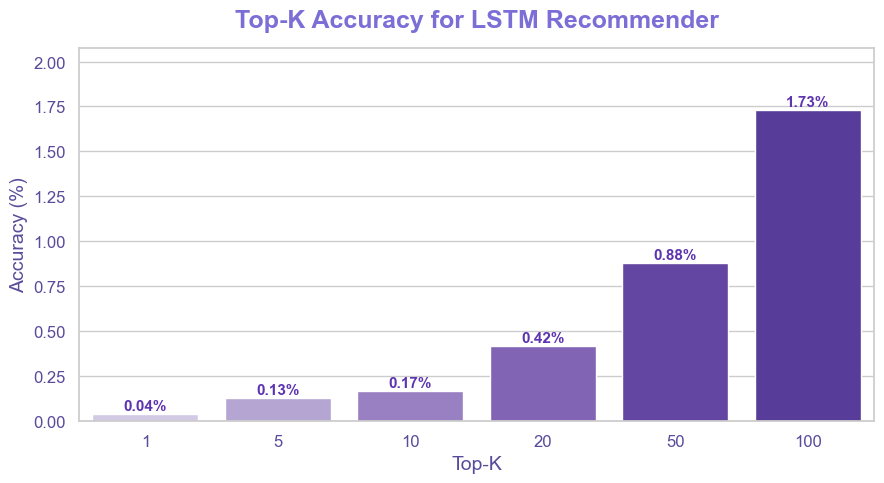

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Data
topk = [1, 5, 10, 20, 50, 100]
accuracy = [0.0004, 0.0013, 0.0017, 0.0042, 0.0088, 0.0173]
accuracy_pct = [a * 100 for a in accuracy]

# Set style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(9, 5))
# Use a list of nice purple-blue colors
custom_palette = ['#D1C4E9', '#B39DDB', '#9575CD', '#7E57C2', '#5E35B1', '#512DA8']

bar = sns.barplot(x=topk, y=accuracy_pct, palette=custom_palette)

# Add value labels
for i, v in enumerate(accuracy_pct):
    plt.text(i, v + 0.02, f"{v:.2f}%", ha='center', fontweight='bold', fontsize=11, color='#5E35B1')

plt.title("Top-K Accuracy for LSTM Recommender", fontsize=18, fontweight='bold', color='#7B6ED6', pad=15)
plt.xlabel("Top-K", fontsize=14, color='#5A4B9B')
plt.ylabel("Accuracy (%)", fontsize=14, color='#5A4B9B')
plt.xticks(fontsize=12, color='#5A4B9B')
plt.yticks(fontsize=12, color='#5A4B9B')
plt.ylim(0, max(accuracy_pct) * 1.2)
plt.tight_layout()
plt.show()


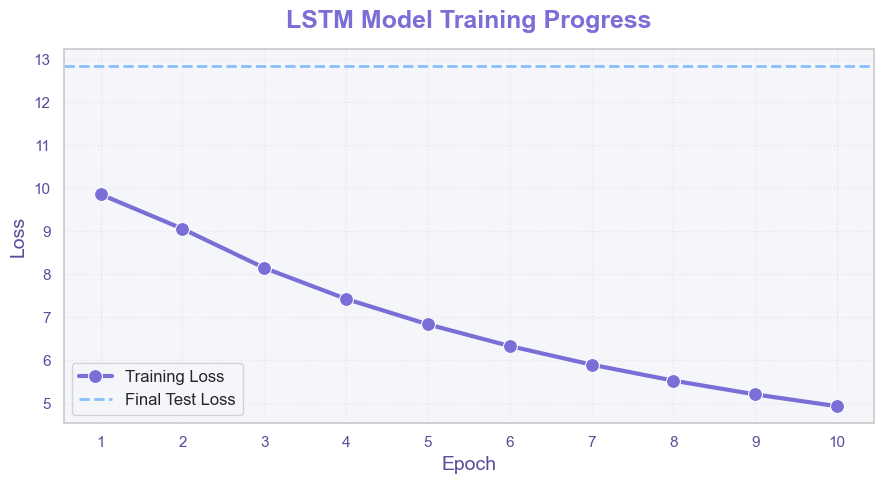

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style
sns.set_theme(style="whitegrid")

# Data
epochs = list(range(1, 11))
train_loss = [9.8636, 9.0626, 8.1521, 7.4310, 6.8391, 6.3351, 5.9025, 5.5304, 5.2105, 4.9357]
test_loss = 12.8508

plt.figure(figsize=(9, 5))

# Pretty purple-blue line for training loss
sns.lineplot(
    x=epochs,
    y=train_loss,
    marker='o',
    color='#7B6ED6',
    linewidth=3,
    markersize=10,
    label='Training Loss'
)

# Soft blue dashed line for final test loss
plt.axhline(
    y=test_loss,
    color='#87BFFF',
    linestyle='--',
    linewidth=2,
    label='Final Test Loss'
)

plt.title("LSTM Model Training Progress", fontsize=18, fontweight='bold', color='#7B6ED6', pad=15)
plt.xlabel("Epoch", fontsize=14, color='#5A4B9B')
plt.ylabel("Loss", fontsize=14, color='#5A4B9B')
plt.xticks(epochs, color='#5A4B9B')
plt.yticks(color='#5A4B9B')
plt.legend(frameon=True, facecolor='#F5F6FA', fontsize=12)
plt.gca().set_facecolor('#F5F6FA')
plt.grid(color='#DED9F3', linestyle=':', linewidth=1, alpha=0.6)
plt.tight_layout()
plt.show()
